In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [148]:
# trasform the csv file to a dataframe 
df = pd.read_csv('C:/Users/ISHMO_CT/Desktop/projects/Loan_ML/Data/loan_data [Task 1-3] - loan_data.csv')

In [149]:
# print the first five rows of the data
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [150]:
# drop the Loan Id columns because it is unque throught so it won't help us in our model
# or we can make it an index 
df = df.set_index('Loan_ID')
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [151]:
# split the data into target and features 
target = 'Loan_Status'
y = df[target]
X = df.drop(columns=target)

In [152]:
# To esnure we have splitted our data the right way I print the shapes of target and features 
print(y.shape)
print(X.shape)

(614,)
(614, 11)


TASK 1


1a. Separate the data into training and test sets (use random_state=42 in the train_test_split for reproducibility).


In [153]:
# split the data into test and train set 
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [154]:
# print out the shapes to make sure I have splitted the datset right 
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(491, 11)
(491,)
(123, 11)
(123,)


1b. Create a model pipeline (for feature transformations)

In [155]:
# identify ordinal columns in features
ordinal_features = ['Dependents']
# define a transformation Pipeline for the ordinal features 
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder()),
    ('scaler', StandardScaler())
])



In [156]:
# Identify categorical columns
nominal_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', ]
#define transformation pipeline for the categorical features
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="MISSING")),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [162]:
# Identify numerical columns 
numerical_features = ['Credit_History', 'Loan_Amount_Term', 'LoanAmount', 'CoapplicantIncome', 'ApplicantIncome']
# Define the tranformation pipeline for the numerical features
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [163]:
# define tuples for the pipelines created and attributes to them 
ordinal_tuples = ('ordinal', ordinal_pipeline, ordinal_features)
nominal_tuples = ('nominal', nominal_pipeline, nominal_features)
numeric_tuples = ('numeric', numerical_pipeline, numerical_features)

In [164]:
# I created a columns tranfromer to inlcude all my pipelines tuples 
column_transformer = ColumnTransformer(transformers=[
    ordinal_tuples,
    nominal_tuples,
    numeric_tuples
]) 

In [165]:
# fit and transform the X_train dataset to the column_trnsformer to make it ready for ready for the model. 
X_train_transformed = column_transformer.fit_transform(X_train)

In [167]:
# transform  the fitted and tranformed X_train set to dataframe 
X_train_transformed = pd.DataFrame(X_train_transformed, columns=column_transformer.get_feature_names_out())
X_train_transformed.head()

,ordinal__Dependents,nominal__Gender_Female,nominal__Gender_MISSING,nominal__Gender_Male,nominal__Married_MISSING,nominal__Married_No,nominal__Married_Yes,nominal__Education_Graduate,nominal__Education_Not Graduate,nominal__Self_Employed_MISSING,nominal__Self_Employed_No,nominal__Self_Employed_Yes,nominal__Property_Area_Rural,nominal__Property_Area_Semiurban,nominal__Property_Area_Urban,numeric__Credit_History,numeric__Loan_Amount_Term,numeric__LoanAmount,numeric__CoapplicantIncome,numeric__ApplicantIncome
0,-0.723275,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.199099e-16,0.295122,1.349134,0.180667,0.083915
1,-0.723275,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.205624,0.385430,-0.429338
2,1.260681,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,0.710987,0.005831,0.126095
3,-0.723275,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.240432,0.464185,-0.576970
4,-0.723275,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-2.434254e+00,0.295122,-0.588512,-0.528127,-0.225522


In [185]:
# lets print the shape to confirm we are using tht right train set 
X_train_transformed.shape

(491, 20)

1. Start by building and evaluating a default decision tree model using appropriate metrics and a confusion matrix.

In [173]:
# we instatiate the our defalut decision tree classifier 
default_dec_tree =  DecisionTreeClassifier(random_state=42)

In [174]:
# Fit the default model 
default_dec_tree.fit(X_train_transformed, y_train)

DecisionTreeClassifier(random_state=42)

In [183]:
# test the model 
# Before I test the model we need to tranform the test set too, to make the data clean and suitable the model 
# However since I have already created the Pipelines lets transform the test set immediately 
X_test_transformed = column_transformer.fit_transform(X_test)
# I transform the array to dataframe in order to capture feature names created during the encoding
X_test_transformed = pd.DataFrame(X_test_transformed, columns=column_transformer.get_feature_names_out())
# print out the first three rows and the shpe to make sure am using the right test set 
X_test_transformed.head(3)


,ordinal__Dependents,nominal__Gender_Female,nominal__Gender_MISSING,nominal__Gender_Male,nominal__Married_MISSING,nominal__Married_No,nominal__Married_Yes,nominal__Education_Graduate,nominal__Education_Not Graduate,nominal__Self_Employed_MISSING,nominal__Self_Employed_No,nominal__Self_Employed_Yes,nominal__Property_Area_Rural,nominal__Property_Area_Semiurban,nominal__Property_Area_Urban,numeric__Credit_History,numeric__Loan_Amount_Term,numeric__LoanAmount,numeric__CoapplicantIncome,numeric__ApplicantIncome
0,-0.797402,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.469058,0.212595,1.233336,-0.906211,0.603713
1,-0.797402,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.212595,-0.095371,-0.906211,-0.103326
2,1.184022,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.469058,0.212595,0.284259,0.029939,-0.124509


In [184]:
# to make sure am using the right test set let me print the shape
X_test_transformed.shape

(123, 20)

In [190]:
# Then now I can test model 
default_test_pred =  default_dec_tree.predict(X_test_transformed)
default_test_pred

array(['Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N',
       'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N',
       'Y', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'N', 'Y', 'Y', 'N'], dtype=object)

In [191]:
# Lets me now evaluate the default model using classification report  and confusion matrix
# Let me start with classification report 
print(classification_report(y_test, default_test_pred))

              precision    recall  f1-score   support

           N       0.49      0.51      0.50        43
           Y       0.73      0.71      0.72        80

    accuracy                           0.64       123
   macro avg       0.61      0.61      0.61       123
weighted avg       0.65      0.64      0.64       123



In [192]:
# Then we print out the confusion_matrix 
confusion_matrix(y_test, default_test_pred)

array([[22, 21],
       [23, 57]])

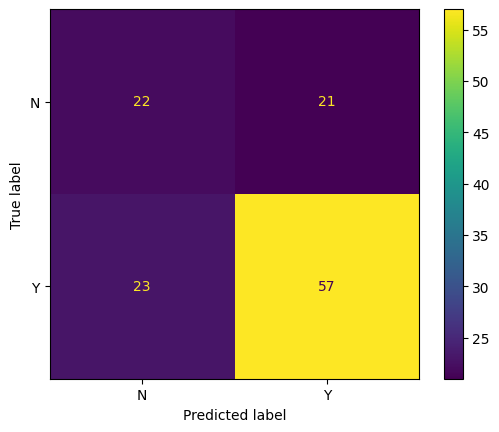

In [193]:
# let me now display it well 
ConfusionMatrixDisplay.from_predictions(y_test, default_test_pred)

Task1. 2. Then, use GridSearchCV to tune the model. Be sure to change the default scoring to "recall_macro" when you instantiate the GridSearch.  (Be sure to explain the GridSearchCV technique)
